# Impact of Reduced Numerical Precision on CNN Accuracy, Calibration, and Robustness

**Models:** FP32 (baseline) · FP16 (half precision) · INT8 (post-training quantization)  
**Dataset:** CIFAR-10  
**Architecture:** ResNet-18  
**Metrics:** Accuracy · Expected Calibration Error (ECE) · Robustness under Gaussian noise

## 1. Imports & Setup

In [1]:
import os, random, copy, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as tvm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
# ── Reproducibility ──────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = "model_wts"
os.makedirs(MODEL_DIR, exist_ok=True)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
print(f"CUDA     : {torch.cuda.is_available()}")

PyTorch  : 2.10.0+cu128
Device   : cuda
CUDA     : True


## 2. CIFAR-10 Data Loaders

In [2]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
])

train_dataset = torchvision.datasets.CIFAR10(root="./data", train=True,  download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=test_transform)

# Small calibration subset (512 samples) for INT8 PTQ
calib_indices  = list(range(512))
calib_dataset  = Subset(train_dataset, calib_indices)

BATCH  = 128
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
calib_loader = DataLoader(calib_dataset, batch_size=64,   shuffle=False, num_workers=2)

CLASSES = test_dataset.classes
print(f"Train samples : {len(train_dataset)}")
print(f"Test  samples : {len(test_dataset)}")
print(f"Calib samples : {len(calib_dataset)}")
print(f"Classes       : {CLASSES}")

Train samples : 50000
Test  samples : 10000
Calib samples : 512
Classes       : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 3. ResNet-18 Definition & FP32 Training

Trained **once** on full CIFAR-10, saved to `model_wts/resnet_fp32.pth`.  
All subsequent evaluations load this single checkpoint — no retraining.

In [4]:
import sys

def build_resnet18(num_classes: int = 10) -> nn.Module:
    """ResNet-18 adapted for CIFAR-10 (32×32 inputs)."""
    model = tvm.resnet18(weights=None)
    # Replace first conv: smaller kernel, no stride, no maxpool
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model



def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for inputs, targets in tqdm(loader,  leave=False):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        correct    += outputs.argmax(1).eq(targets).sum().item()
        total      += inputs.size(0)
    return total_loss / total, 100.0 * correct / total


FP32_PATH = os.path.join(MODEL_DIR, "resnet_fp32.pth")
EPOCHS    = 30

if os.path.exists(FP32_PATH):
    print(f"Checkpoint found: {FP32_PATH} — skipping training.")
else:
    print("Training ResNet-18 on CIFAR-10 (FP32) …")
    fp32_model = build_resnet18().to(DEVICE)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.SGD(fp32_model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_one_epoch(fp32_model, train_loader, criterion, optimizer, DEVICE)
        scheduler.step()
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS} | loss {tr_loss:.4f} | acc {tr_acc:.2f}%")

    torch.save(fp32_model.state_dict(), FP32_PATH)
    print(f"\nSaved → {FP32_PATH}")

🚀  Training ResNet-18 on CIFAR-10 (FP32) …


  Epoch   1/30 | loss 1.9234 | acc 34.73%


  Epoch   5/30 | loss 1.0114 | acc 77.74%


  Epoch  10/30 | loss 0.8318 | acc 85.82%


  Epoch  15/30 | loss 0.7460 | acc 89.44%


  Epoch  20/30 | loss 0.6514 | acc 93.63%


  Epoch  25/30 | loss 0.5567 | acc 97.84%


  Epoch  30/30 | loss 0.5207 | acc 99.37%

💾  Saved → model_wts/resnet_fp32.pth


## 4. Shared Evaluation Helpers

In [31]:
@torch.no_grad()
def evaluate(model, loader, device=DEVICE, half=False, noise_eps=0.0, cpu_model=False):
    """
    Returns (accuracy_pct, all_confidences, all_correct_flags).
    - half       : cast inputs to float16
    - noise_eps  : add Gaussian noise  x' = x + eps * N(0,1), clamped to [0,1]
    - cpu_model  : model runs on CPU (INT8 quantized models are CPU-only)
    """
    model.eval()
    correct, total = 0, 0
    all_conf, all_correct = [], []

    eval_device = torch.device("cpu") if cpu_model else device

    for inputs, targets in loader:
        inputs  = inputs.to(eval_device)
        targets = targets.to(eval_device)

        # Gaussian noise robustness test
        if noise_eps > 0.0:
            noise   = torch.randn_like(inputs) * noise_eps
            inputs  = (inputs + noise).clamp(0.0, 1.0)

        if half:
            inputs = inputs.half()

        outputs = model(inputs)
        probs   = torch.softmax(outputs.float(), dim=1)
        conf, preds = probs.max(1)

        correct += preds.eq(targets).sum().item()
        total   += targets.size(0)

        all_conf.extend(conf.cpu().tolist())
        all_correct.extend(preds.eq(targets).cpu().tolist())

    acc = 100.0 * correct / total
    return acc, np.array(all_conf), np.array(all_correct, dtype=bool)


def compute_ece(confidences, corrects, n_bins=10):
    """
    ECE = Σ_m (|B_m| / n) * |acc(B_m) − conf(B_m)|
    Returns scalar ECE and per-bin (bin_acc, bin_conf, bin_frac) arrays.
    """
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_acc  = np.zeros(n_bins)
    bin_conf = np.zeros(n_bins)
    bin_frac = np.zeros(n_bins)
    n = len(confidences)

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        mask = (confidences > lo) & (confidences <= hi)
        if mask.sum() == 0:
            continue
        bin_acc[i]  = corrects[mask].mean()
        bin_conf[i] = confidences[mask].mean()
        bin_frac[i] = mask.sum() / n

    ece = float(np.sum(bin_frac * np.abs(bin_acc - bin_conf)))
    return ece, bin_acc, bin_conf, bin_frac

print("Helper functions defined.")

Helper functions defined.


## 5. FP32 Baseline Evaluation

In [6]:
# Load checkpoint 
fp32_model = build_resnet18().to(DEVICE)
fp32_model.load_state_dict(torch.load(FP32_PATH, map_location=DEVICE))
fp32_model.eval()

# Clean accuracy 
fp32_acc, fp32_conf, fp32_correct = evaluate(fp32_model, test_loader)
fp32_ece, *fp32_bin_data          = compute_ece(fp32_conf, fp32_correct)

# Noise robustness 
fp32_acc_n1, _, _ = evaluate(fp32_model, test_loader, noise_eps=0.01)
fp32_acc_n2, _, _ = evaluate(fp32_model, test_loader, noise_eps=0.02)

print(f"FP32  Accuracy        : {fp32_acc:.2f}%")
print(f"FP32  ECE             : {fp32_ece:.4f}")
print(f"FP32  Acc (ε=0.01)   : {fp32_acc_n1:.2f}%")
print(f"FP32  Acc (ε=0.02)   : {fp32_acc_n2:.2f}%")

FP32  Accuracy        : 93.75%
FP32  ECE             : 0.0659
FP32  Acc (ε=0.01)   : 53.02%
FP32  Acc (ε=0.02)   : 53.10%


## 6. FP16 Evaluation
Convert the loaded FP32 model to half precision. BatchNorm layers are kept in FP32 for numerical stability.

In [7]:
# Cast whole model to FP16
fp16_model = build_resnet18().to(DEVICE)
fp16_model.load_state_dict(torch.load(FP32_PATH, map_location=DEVICE))

# Keep BatchNorm in FP32 for numerical stability during inference
fp16_model.half()
for m in fp16_model.modules():
    if isinstance(m, (nn.BatchNorm1d, nn.BatchNorm2d, nn.BatchNorm3d)):
        m.float()

fp16_model.eval()

#  Evaluate 
fp16_acc, fp16_conf, fp16_correct = evaluate(fp16_model, test_loader, half=True)
fp16_ece, *fp16_bin_data          = compute_ece(fp16_conf, fp16_correct)

fp16_acc_n1, _, _ = evaluate(fp16_model, test_loader, half=True, noise_eps=0.01)
fp16_acc_n2, _, _ = evaluate(fp16_model, test_loader, half=True, noise_eps=0.02)

print(f"FP16  Accuracy        : {fp16_acc:.2f}%")
print(f"FP16  ECE             : {fp16_ece:.4f}")
print(f"FP16  Acc (ε=0.01)   : {fp16_acc_n1:.2f}%")
print(f"FP16  Acc (ε=0.02)   : {fp16_acc_n2:.2f}%")

FP16  Accuracy        : 93.75%
FP16  ECE             : 0.0662
FP16  Acc (ε=0.01)   : 53.06%
FP16  Acc (ε=0.02)   : 53.17%


## 7 · INT8 Post-Training Static Quantization

Steps:
1. Fuse `Conv → BN → ReLU` triples  
2. Insert `QuantStub` / `DeQuantStub` observers  
3. Calibrate on 512-sample subset  
4. Convert to INT8  
5. Evaluate on full test set (CPU — PyTorch static quant is CPU-only)

In [12]:
import torch
print(torch.__version__)
print(torch.backends.quantized.supported_engines)

2.10.0+cu128
['qnnpack', 'onednn', 'x86', 'fbgemm']


In [34]:
import torch.ao.quantization as tq
from torch.ao.quantization import get_default_qconfig
from torch.ao.quantization.quantize_fx import prepare_fx, convert_fx

torch.backends.quantized.engine = "fbgemm"

# Build FP32 Model
model_fp32 = build_resnet18()
model_fp32.load_state_dict(torch.load(FP32_PATH, map_location="cpu"))
model_fp32.eval()
model_fp32.cpu()

# FX Quantization Setup
qconfig = get_default_qconfig("fbgemm")
qconfig_dict = {"": qconfig}

# Required example input for FX tracing
example_input = torch.randn(1, 3, 32, 32)

print("Preparing FX graph...")
model_prepared = prepare_fx(model_fp32, qconfig_dict, example_input)

# Calibration
print(f"Calibrating on {len(calib_dataset)} samples...")

with torch.no_grad():
    for i, (inputs, _) in enumerate(calib_loader):
        inputs = inputs.cpu()
        model_prepared(inputs)
        if i > 5:  # ~1000 samples is enough
            break

# Convert to INT8
print("Converting to INT8...")
model_int8 = convert_fx(model_prepared)
model_int8.eval()
model_int8.cpu()

print("INT8 model ready.")

Preparing FX graph...
Calibrating on 512 samples...
Converting to INT8...
INT8 model ready.


In [27]:
#  Evaluate INT8 (CPU-only)
int8_acc, int8_conf, int8_correct = evaluate(model_int8, test_loader, cpu_model=True)
int8_ece, *int8_bin_data          = compute_ece(int8_conf, int8_correct)
    
int8_acc_n1, _, _ = evaluate(model_int8.to("cpu"), test_loader, cpu_model=True, noise_eps=0.01)
int8_acc_n2, _, _ = evaluate(model_int8.to("cpu"), test_loader, cpu_model=True, noise_eps=0.02)
print(f"INT8  Accuracy        : {int8_acc:.2f}%")
print(f"INT8  ECE             : {int8_ece:.4f}")
print(f"INT8  Acc (ε=0.01)   : {int8_acc_n1:.2f}%")
print(f"INT8  Acc (ε=0.02)   : {int8_acc_n2:.2f}%")

INT8  Accuracy        : 93.75%
INT8  ECE             : 0.0651
INT8  Acc (ε=0.01)   : 53.45%
INT8  Acc (ε=0.02)   : 53.20%


## 8 · Results Summary Table

In [28]:
results = {
    "Precision" : ["FP32",    "FP16",    "INT8"],
    "Acc (%)":    [fp32_acc,  fp16_acc,  int8_acc],
    "ECE":        [fp32_ece,  fp16_ece,  int8_ece],
    "Acc ε=0.01": [fp32_acc_n1, fp16_acc_n1, int8_acc_n1],
    "Acc ε=0.02": [fp32_acc_n2, fp16_acc_n2, int8_acc_n2],
}

header = f"{'Precision':<12} {'Acc (%)':>9} {'ECE':>8} {'Acc ε=0.01':>12} {'Acc ε=0.02':>12}"
sep    = "-" * len(header)
print(sep)
print(header)
print(sep)
for i, prec in enumerate(results["Precision"]):
    print(f"{prec:<12} {results['Acc (%)'][i]:>9.2f} {results['ECE'][i]:>8.4f}"
          f" {results['Acc ε=0.01'][i]:>12.2f} {results['Acc ε=0.02'][i]:>12.2f}")
print(sep)

---------------------------------------------------------
Precision      Acc (%)      ECE   Acc ε=0.01   Acc ε=0.02
---------------------------------------------------------
FP32             93.75   0.0659        53.02        53.10
FP16             93.75   0.0662        53.06        53.17
INT8             93.75   0.0651        53.45        53.20
---------------------------------------------------------


## 9 · Plots

**Plot 1** — Accuracy vs Precision  
**Plot 2** — ECE vs Precision  
**Plot 3** — Accuracy vs Noise (3 curves)

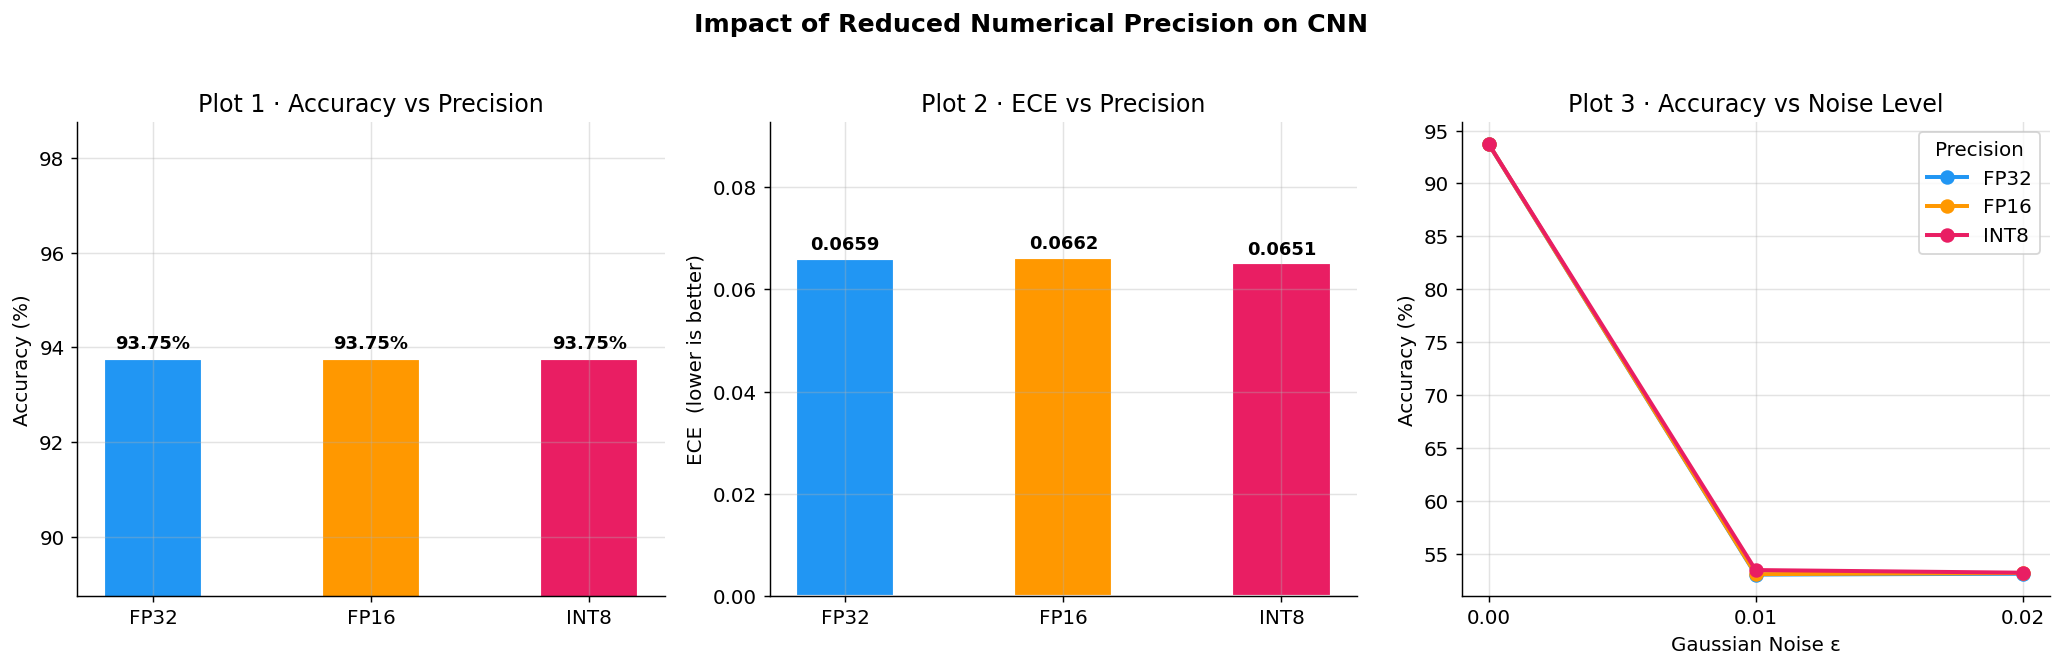

Figure saved → precision_comparison.png


In [36]:
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 11,
})

PRECISIONS  = ["FP32", "FP16", "INT8"]
COLORS      = ["#2196F3", "#FF9800", "#E91E63"]  # blue, orange, pink
x_pos       = np.arange(len(PRECISIONS))
BAR_W       = 0.45

accs  = [fp32_acc,  fp16_acc,  int8_acc]
eces  = [fp32_ece,  fp16_ece,  int8_ece]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Impact of Reduced Numerical Precision on CNN", fontsize=14, fontweight="bold", y=1.02)

#  Plot 1: Accuracy vs Precision 
ax = axes[0]
bars = ax.bar(x_pos, accs, width=BAR_W, color=COLORS, edgecolor="white", linewidth=1.2)
ax.set_xticks(x_pos); ax.set_xticklabels(PRECISIONS)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Plot 1 · Accuracy vs Precision")
ax.set_ylim(max(0, min(accs) - 5), min(100, max(accs) + 5))
for bar, v in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{v:.2f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Plot 2: ECE vs Precision 
ax = axes[1]
bars = ax.bar(x_pos, eces, width=BAR_W, color=COLORS, edgecolor="white", linewidth=1.2)
ax.set_xticks(x_pos); ax.set_xticklabels(PRECISIONS)
ax.set_ylabel("ECE  (lower is better)")
ax.set_title("Plot 2 · ECE vs Precision")
ax.set_ylim(0, max(eces) * 1.4)
for bar, v in zip(bars, eces):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f"{v:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Plot 3: Accuracy vs Noise (3 curves) 
ax = axes[2]
noise_levels = [0.0, 0.01, 0.02]
fp32_noise   = [fp32_acc,  fp32_acc_n1, fp32_acc_n2]
fp16_noise   = [fp16_acc,  fp16_acc_n1, fp16_acc_n2]
int8_noise   = [int8_acc,  int8_acc_n1, int8_acc_n2]

for vals, label, color in zip(
        [fp32_noise, fp16_noise, int8_noise],
        PRECISIONS, COLORS):
    ax.plot(noise_levels, vals, marker="o", linewidth=2.2,
            markersize=7, label=label, color=color)

ax.set_xlabel("Gaussian Noise ε")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Plot 3 · Accuracy vs Noise Level")
ax.set_xticks(noise_levels)
ax.legend(title="Precision", framealpha=0.8)

plt.tight_layout()
plt.savefig("fig/precision_comparison.png", bbox_inches="tight")
plt.show()
print("Figure saved → precision_comparison.png")

## 10 · Reliability Diagrams (Calibration Detail)

One diagram per precision variant — shows per-bin gap between average confidence and actual accuracy.

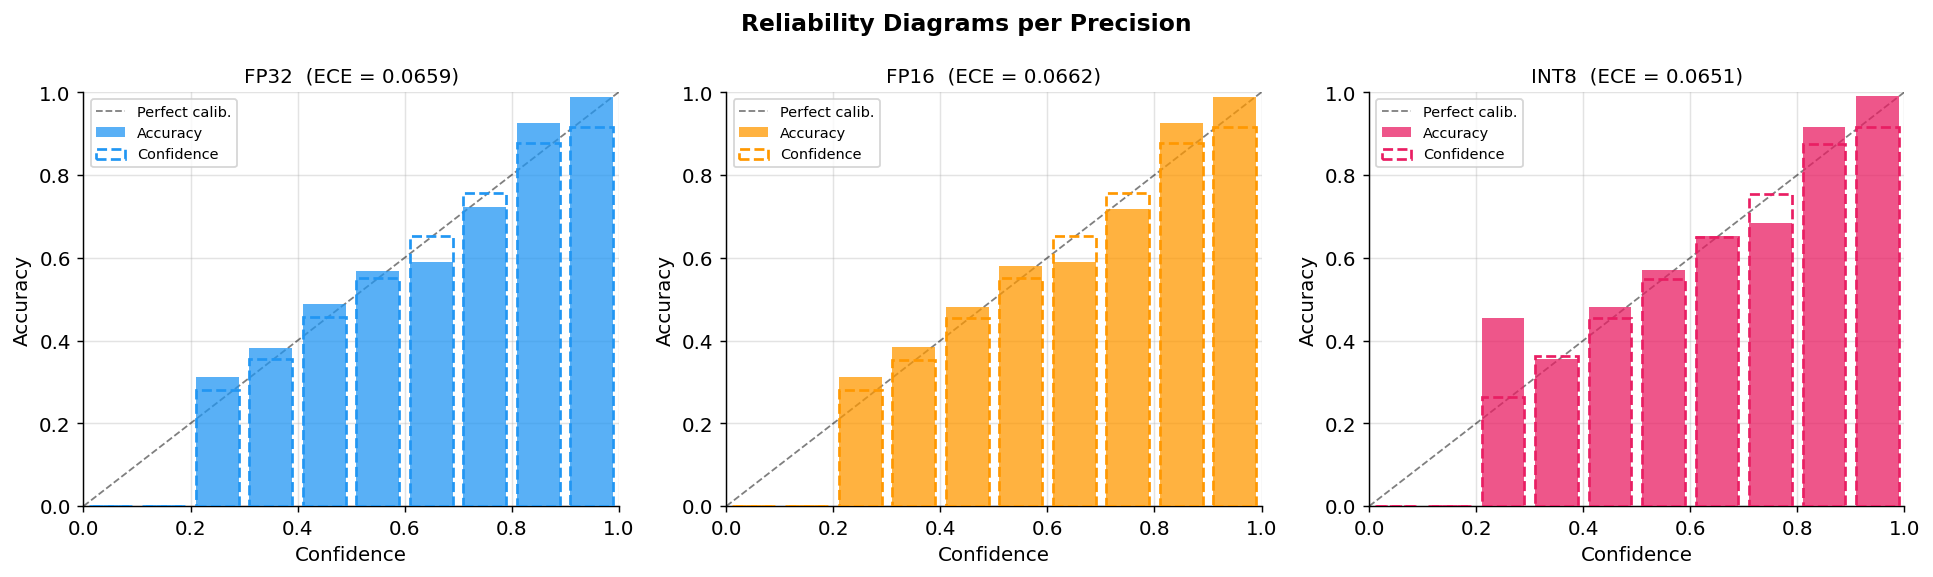

Figure saved → reliability_diagrams.png


In [37]:
def plot_reliability(ax, bin_acc, bin_conf, bin_frac, title, color, ece_val):
    n_bins   = len(bin_acc)
    bin_mid  = np.linspace(0.05, 0.95, n_bins)
    width    = 0.08

    ax.bar(bin_mid, bin_acc,  width=width, color=color, alpha=0.75, label="Accuracy",    zorder=3)
    ax.bar(bin_mid, bin_conf, width=width, color="none",
           edgecolor=color, linestyle="--", linewidth=1.5, label="Confidence", zorder=4)
    ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Perfect calib.")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Confidence"); ax.set_ylabel("Accuracy")
    ax.set_title(f"{title}  (ECE = {ece_val:.4f})", fontsize=11)
    ax.legend(fontsize=8, loc="upper left")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Reliability Diagrams per Precision", fontsize=13, fontweight="bold")

data_pairs = [
    (fp32_bin_data, "FP32",  COLORS[0], fp32_ece),
    (fp16_bin_data, "FP16",  COLORS[1], fp16_ece),
    (int8_bin_data, "INT8",  COLORS[2], int8_ece),
]
for ax, (bd, title, col, ece) in zip(axes, data_pairs):
    b_acc, b_conf, b_frac = bd
    plot_reliability(ax, b_acc, b_conf, b_frac, title, col, ece)

plt.tight_layout()
plt.savefig("fig/reliability_diagrams.png", bbox_inches="tight")
plt.show()
print("Figure saved → reliability_diagrams.png")